In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\THIEN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 1. Load Dataset

In [3]:
df = pd.read_csv("email.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(f"shape: {df.shape} \n")
df.info()
print("\n")
df.describe()

shape: (5573, 2) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB




,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


In [5]:
df['Category'].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

# 2. Tiền xử lí dữ liệu

In [6]:
df = df[df['Category'].isin(['ham', 'spam'])]

In [7]:
print(f"ham: {round((4825/5572) *100, 2)}%")
print(f"spam: {round((747/5572) *100, 2)}%")

ham: 86.59%
spam: 13.41%


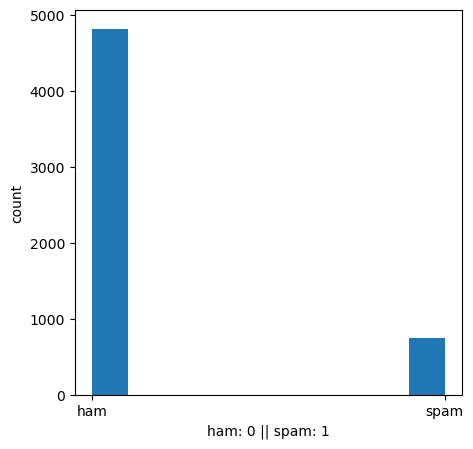

In [8]:
plt.figure(figsize=(5,5));
plt.plot()
plt.hist(df['Category']);
plt.xlabel('ham: 0 || spam: 1');
plt.ylabel('count');

In [9]:
df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

In [12]:
df['Category'].value_counts()

Category
0    4825
1     747
Name: count, dtype: int64

In [13]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # lowercase
    text = text.lower()
    # remove punctuation & number
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # tokenize
    words = text.split()
    # remove stopwords
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Message'].apply(clean_text)

# 3. Xử lí dữ liệu

In [14]:
x, y = df['clean_text'], df['Category']

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
vectorizer = TfidfVectorizer()

vectorizer.fit(x_train)

x_train_tfidf = vectorizer.transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [19]:
print(x.shape)
print(y.shape)

(5572,)
(5572,)


# 4. Huấn luyện model

In [21]:
NB_Model = MultinomialNB()
LR_Model = LogisticRegression(
    class_weight="balanced"
)

NB_Model.fit(x_train_tfidf, y_train)
LR_Model.fit(x_train_tfidf, y_train)

LogisticRegression(class_weight='balanced')

In [23]:
y_pred_NB = NB_Model.predict(x_test_tfidf)
y_pred_LR = LR_Model.predict(x_test_tfidf)

In [25]:
print(f"Naive Bayes \n {classification_report(y_test, y_pred_NB)} \n")
print(f"Logistics Regression \n {classification_report(y_test, y_pred_LR)}")

Naive Bayes 
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115
 

Logistics Regression 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.92      0.91      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



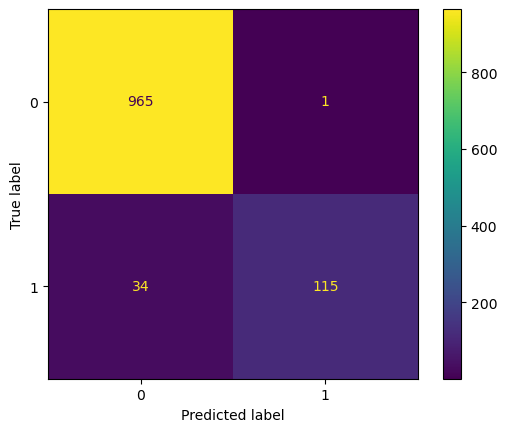

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

# y_test: nhãn thật
# y_pred: nhãn model dự đoán

cm = confusion_matrix(y_test, y_pred_NB)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

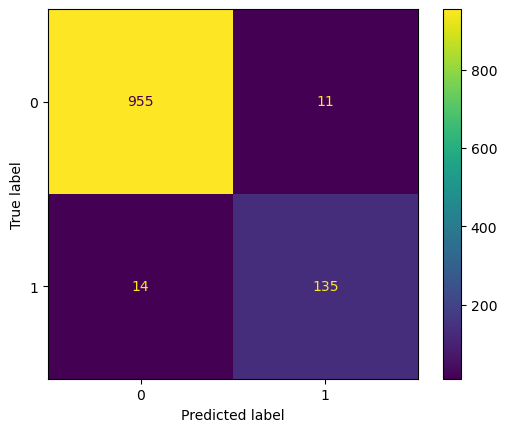

In [27]:
lrcm = confusion_matrix(y_test, y_pred_LR)

disp = ConfusionMatrixDisplay(confusion_matrix=lrcm)
disp.plot()

plt.show()